In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1D, FDEM1DModelling, LCModelling
from showStitched import showStitchedModels
from Plot import Plot_Datas

In [3]:
# First step: check configuration of FDEM to perform forward
# Second step: check number of layers in FDEM1D Modelling forward class

In [4]:
## Create a test model

pos = 30
nLayers = 2

x =  np.linspace(0,pos,pos, endpoint=False)
sigm_1 = 200/1000
sigm_2 = 1250/1000
#sigm_3 = 100/1000
#sigm_4 = 25/1000
thk_1 = 4* np.ones(pos) #- (x/100)  # - [0.5, 0.6, 0.7, .8, .9, 1, 0.9, 0.8, 0.7, 0.6]
#thk_2 = 3*np.ones(pos)   #+ 2*np.array([0.5, 0.6, 0.7, .8, .9, 1, 0.9, 0.8, 0.7, 0.6])
#thk_3 = np.ones_like(x)*2

models = np.zeros((pos, nLayers*2-1))
models[:,0] = thk_1
#models[:,1] = thk_2
#models[:,2] = thk_3
models[:,1] = sigm_1
models[:,2] = sigm_2
#models[:,3] = sigm_2
#models[:,4] = sigm_3
#models[:,6] = sigm_4

nSoundings = pos

## Create test data

data_t = []

# 3 lay case
for p in range(pos):
    data_t.append(FDEM1D(models[p,1:], models[p,:1]))

# 4 lay case
#for p in range(pos):
#    data_t.append(FDEM1D(models[p,3:], models[p,:3]))



In [5]:
np.save('modelLCI', models)

In [6]:
np.save('dataLCI', data_t)
#data_3D = np.load('dataLCI_3D.npy').reshape(np.shape(data_t))

<AxesSubplot:title={'center':'True Model'}>

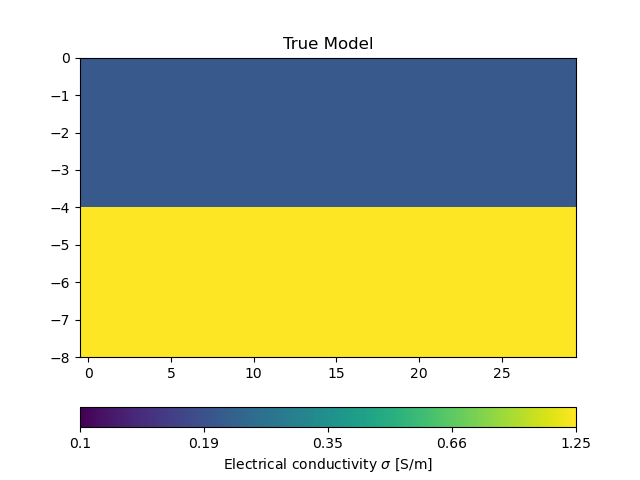

In [7]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 100/1000,
         'cMax': 1250/1000}

showStitchedModels(models, zMax=8, title = 'True Model', **inputs)

# LCI

In [13]:
LC = LCModelling(FDEM1DModelling)

Inversion is normalized


In [14]:
LC.initJacobian(dataVals=data_t, nLay=nLayers)
LC.createJacobian(models)
LC.constraint_matrix(data_t, nLay=nLayers)
LC.normalization(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createWeight(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createConstraints()


Jacobian size: 522 87 540
cWeights are equal
Constraint cWeight length: 87
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f4894e73a90>


In [15]:
RM = LC.regionManager()
RM.regionIdxs()

2 [1, 2]

# Inversion

In [16]:
# Initial model
m0 = models.copy()

# 3 lay case
m0[:,:1] = 2
m0[:,1:] = 500/1000

m0 = m0.ravel()

# 4 lay case
#m0[:,:3] = 2
#m0[:,3:] = 50/1000

In [17]:
transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(1,4)
transSig = pg.trans.TransLogLU(100/1000,1250/1000)

LC.region(1).setTransModel(transThk)
LC.region(2).setTransModel(transSig)

data_true = np.array(data_t).ravel()
relativeError = np.ones_like(data_true)*1e-3 # what is this for?

inv = pg.Inversion(LC)
inv.dataTrans = transData
models_est = inv.run(data_true, relativeError, startModel=m0, verbose=False)

15/03/24 - 10:16:19 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
15/03/24 - 10:16:19 - pyGIMLi - INFO - Starting model set from given array. [2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5
 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5
 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5
 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5
 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5 2.  0.5 0.5]
15/03/24 - 10:16:19 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


<AxesSubplot:title={'center':'True Model LCI'}>

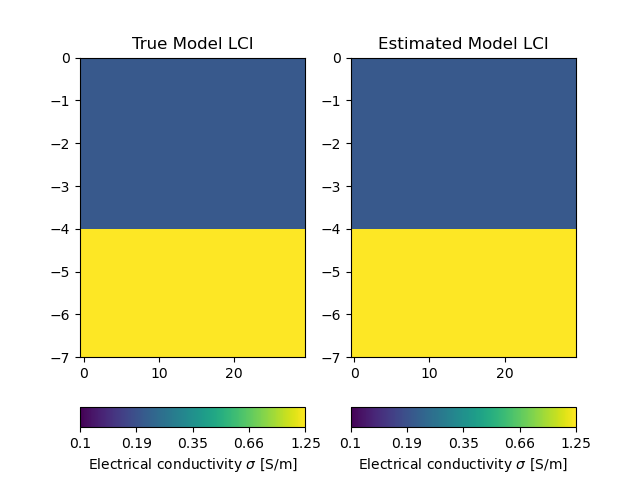

In [18]:
models_est = np.array(models_est).reshape(np.shape(models))

fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 100/1000,
         'cMax': 1250/1000, 
         'logScale':True}

showStitchedModels(ax = ax[1], models=models_est, zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'True Model LCI', **inputs)


### Inversion with L-curve criterion

In [139]:
# Define inversion
#LC.region(1).setConstraintType(10)
#LC.region(2).setConstraintType(10)

# Why is the behaviour so strange ??? when you change the limits

Lcurve = True

chi2 = 1.1
dPhi = 2.1
phi0 = 0
chi2s = []
phis = []
maxIter = 20
ii = 0

print('Started inversion ...')
while Lcurve and (chi2 > 1) and (dPhi > 2) and (ii < maxIter):
    
    
    print('Iteration number: ', ii+1)
    
    #print('Running L-curve criterion')
    lambdas = np.logspace(-1,3,20)
        
    phimodels = []
    phidatas = []
    chis = []
    mods = {}

    for i, a in enumerate(lambdas):
        #print(f'Now using LAMBDA {a} - {i} ITERATION')
        inv = pg.Inversion(LC)
        inv.dataTrans = transData
        mod = inv.run(data_true, relativeError, startModel=m0, verbose=False, lam=a)
        phimodels.append(inv.phiModel())
        phidatas.append(inv.phiData())
        chis.append(inv.chi2())
        mods[a] = mod

    # first derivatives
    dx = np.gradient(phimodels)
    dy = np.gradient(phidatas)

    # second derivatives
    d2x = np.gradient(dx)
    d2y = np.gradient(dy)

    # calculation of curvature
    curvature = np.abs(dx * d2y - d2x * dy)/(dx * dx + dy * dy)**1.5
    print('The optimal alpha =', lambdas[np.argmax(curvature)+1])

    lamb_opt = lambdas[np.argmax(curvature)+1]
    
    inv = pg.Inversion(LC)
    inv.dataTrans = transData
    models_est = inv.run(data_true, relativeError, startModel=m0, 
                         verbose=False, lam=lamb_opt, maxIter=1)
    
    chi2 = inv.chi2()
    chi2s.append(chi2)
    print('Chi2: ', chi2)
    
    phi1 = inv.phi()
    dPhi = np.abs((phi1 - phi0)/phi1)*100
    phis.append(phi1)
    print('dPhi: ', dPhi)

    phi0 = phi1
    m0 = models_est.copy()
    
    ii +=1
    

#plt.figure()
#plt.scatter(phimodels, phidatas, c='g')
#plt.xlabel('Phi Model')
#plt.ylabel('Phi Data')
#plt.title('L-curve analysis')
#for i, txt in enumerate(lambdas):
#    txt = np.round(txt,3)
#    txt = str(txt)
#    plt.annotate(txt, (phimodels[i], phidatas[i]))
#plt.plot(phimodels[np.argmax(curvature)+1], phidatas[np.argmax(curvature)+1], 'b')
#plt.show()


12/03/24 - 16:48:37 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 16:48:37 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 16:48:37 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


Started inversion ...
Iteration number:  1


12/03/24 - 16:48:42 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 16:48:42 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 16:48:42 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


12/03/24 - 16:48:48 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 16:48:48 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 16:48:48 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


12/03/24 - 16:48:53 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 16:48:53 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 16:48:53 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


...

12/03/24 - 17:03:39 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 17:03:39 - pyGIMLi - INFO - Starting model set from given array. 50 [2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889

12/03/24 - 17:03:40 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 17:03:40 - pyGIMLi - INFO - Starting model set from given array. 50 [2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889

12/03/24 - 17:03:41 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 17:03:41 - pyGIMLi - INFO - Starting model set from given array. 50 [2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889

12/03/24 - 17:03:42 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 17:03:42 - pyGIMLi - INFO - Starting model set from given array. 50 [2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889964533, 0.19998209992325575, 1.246162538687208, 0.10407579684707291, 2.996861758145117, 3.0158931889



The optimal alpha = 0.16237767391887217
Chi2:  0.09916786599028132
dPhi:  1148.54998176985


In [140]:
#inv = pg.Inversion(LC)
#inv.dataTrans = transData
#models_est = inv.run(data_true, relativeError, startModel=m0.ravel(), verbose=True, lam=lamb_opt)

<AxesSubplot:title={'center':'True Model LCI'}>

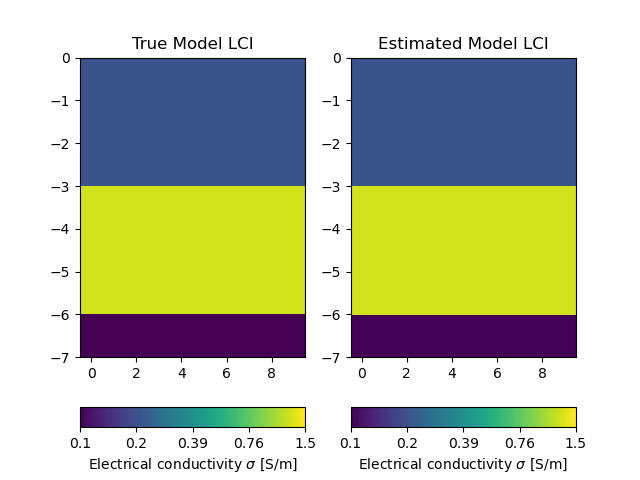

In [142]:
models_est = np.array(models_est).reshape(np.shape(models))

fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 100/1000,
         'cMax': 1500/1000, 
         'logScale':True}

showStitchedModels(ax = ax[1], models=models_est, zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'True Model LCI', **inputs)


In [143]:
data_est = inv.fop.response(models_est)

# Reshape data arrays [pos, n_components, n_geometries, n_offsets]
data_true = np.array(data_t).reshape(pos,2,3,3)
data_est = np.array(data_est).reshape(pos,2,3,3)

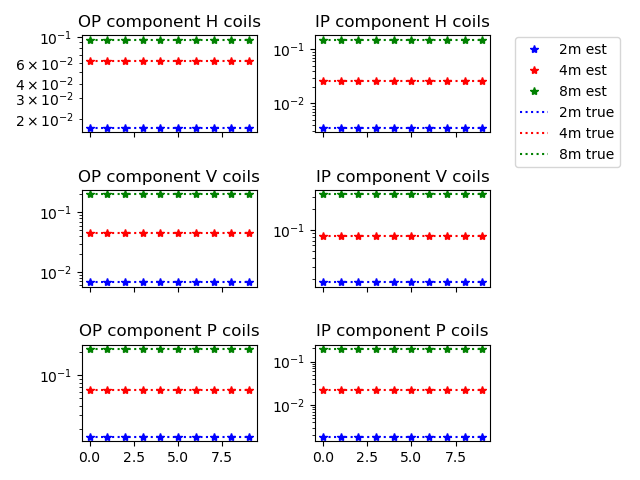

In [144]:
Plot_Datas(data_true, data_est)

## LCI with 3D data

In [83]:
data_3D = np.load('dataLCI_3D.npy').reshape(np.shape(data_t))

In [84]:
data_t = data_3D.copy()

In [85]:
LC = LCModelling(FDEM1DModelling)

Inversion is normalized


In [86]:
LC.initJacobian(dataVals=data_t, nLay=nLayers)
LC.createJacobian(models)
LC.constraint_matrix(data_t, nLay=nLayers)
LC.normalization(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createWeight(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createConstraints()


Jacobian size: 162 45 180
cWeights are equal
Constraint cWeight length: 45
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fe336d3c220>


### Inversion 

In [107]:
# Initial model
m0 = models.copy()

# 3 lay case
m0[:,:2] = 2
m0[:,2:] = 500/1000

m0 = m0.ravel()

In [108]:
transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(2,5)
transSig = pg.trans.TransLogLU(100/1000,1250/1000)

LC.region(1).setTransModel(transThk)
LC.region(2).setTransModel(transSig)

data_true = np.array(data_t).ravel()
relativeError = np.ones_like(data_true)*1e-3 # what is this for?

inv = pg.Inversion(LC)
inv.dataTrans = transData
models_est = inv.run(data_true, relativeError, startModel=m0, verbose=False)

12/03/24 - 14:51:48 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 14:51:48 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 14:51:48 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


<AxesSubplot:title={'center':'True Model LCI'}>

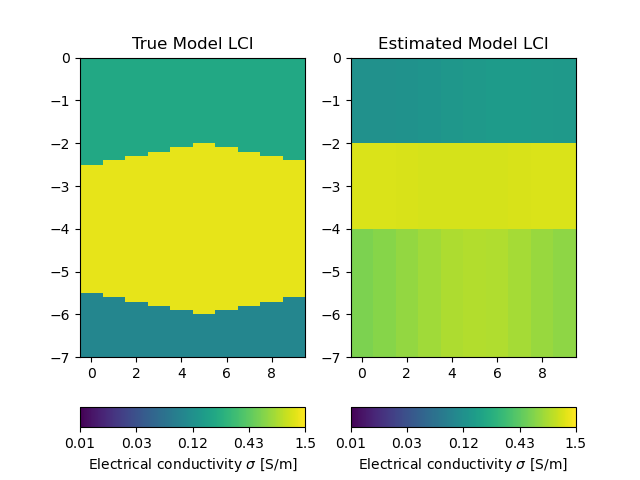

In [109]:
models_est = np.array(models_est).reshape(np.shape(models))

fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 1500/1000, 
         'logScale':True}

showStitchedModels(ax = ax[1], models=models_est, zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'True Model LCI', **inputs)

## Inversion with L-curve criterion

In [110]:
Lcurve = True

LC = LCModelling(FDEM1DModelling)

LC.initJacobian(dataVals=data_t, nLay=nLayers)
LC.createJacobian(models)
LC.constraint_matrix(data_t, nLay=nLayers)
LC.normalization(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createWeight(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LC.createConstraints()

transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(1,4)
transSig = pg.trans.TransLogLU(100/1000,1250/1000)

LC.region(1).setTransModel(transThk)
LC.region(2).setTransModel(transSig)

data_true = np.array(data_t).ravel()
relativeError = np.ones_like(data_true)*1e-3 # what is this for?

#m0 = models_est.ravel()

chi2 = 1.1
dPhi = 2.1
phi0 = 0
chi2s = []
phis = []
maxIter = 20
ii = 0

print('Started inversion ...')
while Lcurve and (chi2 > 1) and (dPhi > 2) and (ii < maxIter):
    
    
    print('Iteration number: ', ii+1)
    
    #print('Running L-curve criterion')
    lambdas = np.logspace(-1,3,20)
        
    phimodels = []
    phidatas = []
    chis = []
    mods = {}

    for i, a in enumerate(lambdas):
        #print(f'Now using LAMBDA {a} - {i} ITERATION')
        inv = pg.Inversion(LC)
        inv.dataTrans = transData
        mod = inv.run(data_true, relativeError, startModel=m0, verbose=False, lam=a)
        phimodels.append(inv.phiModel())
        phidatas.append(inv.phiData())
        chis.append(inv.chi2())
        mods[a] = mod

    # first derivatives
    dx = np.gradient(phimodels)
    dy = np.gradient(phidatas)

    # second derivatives
    d2x = np.gradient(dx)
    d2y = np.gradient(dy)

    # calculation of curvature
    curvature = np.abs(dx * d2y - d2x * dy)/(dx * dx + dy * dy)**1.5
    print('The optimal alpha =', lambdas[np.argmax(curvature)+1])

    lamb_opt = lambdas[np.argmax(curvature)+1]
    
    inv = pg.Inversion(LC)
    inv.dataTrans = transData
    models_est = inv.run(data_true, relativeError, startModel=m0, 
                         verbose=False, lam=lamb_opt, maxIter=1)
    
    chi2 = inv.chi2()
    chi2s.append(chi2)
    print('Chi2: ', chi2)
    
    phi1 = inv.phi()
    dPhi = np.abs((phi1 - phi0)/phi1)*100
    phis.append(phi1)
    print('dPhi: ', dPhi)

    phi0 = phi1
    m0 = models_est.copy()
    
    ii +=1

Inversion is normalized
Jacobian size: 162 45 180


12/03/24 - 14:52:03 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 14:52:03 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 14:52:03 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 45
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fe33155ab80>
Started inversion ...
Iteration number:  1


12/03/24 - 14:52:06 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 14:52:06 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 14:52:06 - Core - ERROR - no cWeights defined. You should create constraints matrix first.
12/03/24 - 14:52:08 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 14:52:08 - pyGIMLi - INFO - Starting model set from given array. [2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5
 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.
 2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5 2.  2.  0.5 0.5 0.5]
12/03/24 - 14:52:08 - Core - ERROR - no cWeights defined. You should create constraints matrix first.
12/03/24 - 14:52:10 - Core - WARNING - no clear() implemente

The optimal alpha = 0.42813323987193935


...

The optimal alpha = 1.8329807108324356


12/03/24 - 14:58:47 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 14:58:47 - pyGIMLi - INFO - Starting model set from given array. 50 [1.953088048703225, 1.0000000100000015, 0.12114676621353827, 1.148217461721348, 0.7267371961938827, 1.9310794574339445, 1.0000000100000015, 0.12132302334199811, 1.1407730205340694, 0.7442694720652359, 1.8953065117848649, 1.0000000100000015, 0.12192831288855992, 1.1262112287264074, 0.7702668089005874, 1.8543242485221398, 1.0000000100000013, 0.12306802245035803, 1.1067416256340943, 0.7977767585872091, 1.826482733854663, 1.0000000100000013, 0.12462851527032401, 1.0871299730544792, 0.8169103235414857, 1.8065393378593635, 1.0000000100000013, 0.12642425926928488, 1.0751495223798977, 0.8244756135505282, 1.7790202922514657, 1.0000000100000013, 0.12811174274093964, 1.0782920113036196, 0.8216422442000995, 1.7629787573566487, 1.0000000100000013, 0.12890723027765494, 1.0921025889660336, 0.8069493669988712, 1.7754883805269455, 1.0000

Chi2:  4899.752730979622
dPhi:  2.7811542862970238
Iteration number:  12


12/03/24 - 14:58:49 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/03/24 - 14:58:49 - pyGIMLi - INFO - Starting model set from given array. 50 [1.953088048703225, 1.0000000100000015, 0.12114676621353827, 1.148217461721348, 0.7267371961938827, 1.9310794574339445, 1.0000000100000015, 0.12132302334199811, 1.1407730205340694, 0.7442694720652359, 1.8953065117848649, 1.0000000100000015, 0.12192831288855992, 1.1262112287264074, 0.7702668089005874, 1.8543242485221398, 1.0000000100000013, 0.12306802245035803, 1.1067416256340943, 0.7977767585872091, 1.826482733854663, 1.0000000100000013, 0.12462851527032401, 1.0871299730544792, 0.8169103235414857, 1.8065393378593635, 1.0000000100000013, 0.12642425926928488, 1.0751495223798977, 0.8244756135505282, 1.7790202922514657, 1.0000000100000013, 0.12811174274093964, 1.0782920113036196, 0.8216422442000995, 1.7629787573566487, 1.0000000100000013, 0.12890723027765494, 1.0921025889660336, 0.8069493669988712, 1.7754883805269455, 1.0000

The optimal alpha = 1.8329807108324356
Chi2:  4839.735550595085
dPhi:  1.0648094037887357


<AxesSubplot:title={'center':'True Model LCI'}>

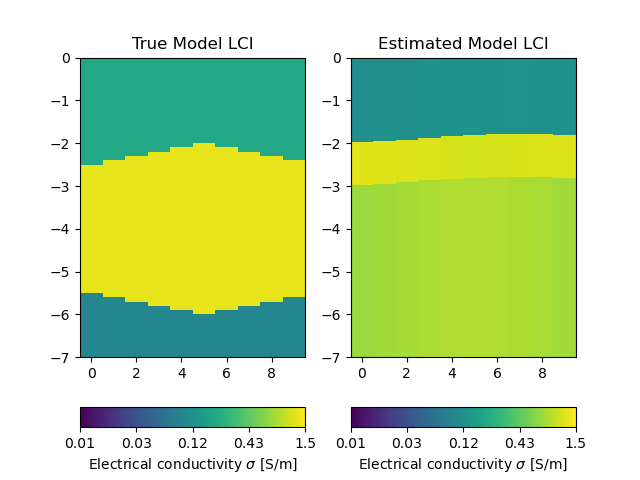

In [111]:
models_est = np.array(models_est).reshape(np.shape(models))

fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 1500/1000, 
         'logScale':True}

showStitchedModels(ax = ax[1], models=models_est, zMax=7, 
                  title = 'Estimated Model LCI', **inputs)

showStitchedModels(ax = ax[0], models=models, zMax=7, 
                  title = 'True Model LCI', **inputs)


In [112]:
data_est = inv.fop.response(models_est)

# Reshape data arrays [pos, n_components, n_geometries, n_offsets]
data_true = np.array(data_t).reshape(pos,2,3,3)
data_est = np.array(data_est).reshape(pos,2,3,3)

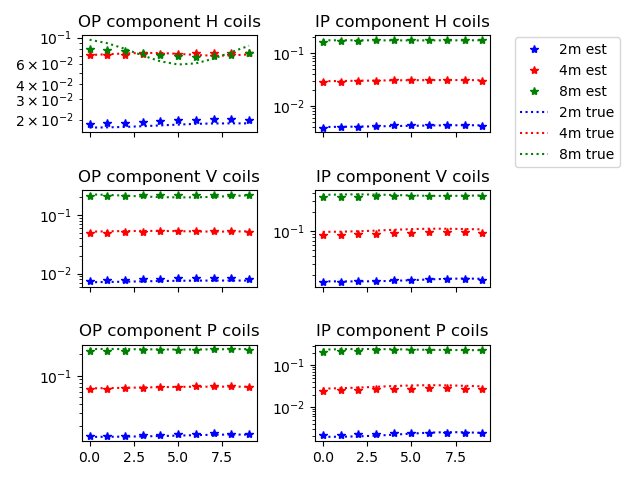

In [113]:
Plot_Datas(data_true, data_est)

## Sort 3D Data

In [9]:
xsrc = np.linspace(-4, 13, 18, endpoint=True)

OUT = pd.DataFrame({})

for p in range(18):
    print('Position:', p)
    print('Defining geometry')
    # Define source coordinates
    src_x = xsrc[p]
    Hsrc_coords = [src_x, 0, 0, 0, 90]
    Vsrc_coords = [src_x, 0, 0, 90, 0]
    print('source:', Hsrc_coords)
    
    # Define H and V receivers coordinates
    offsets_HV = np.array([xsrc[p]+2, xsrc[p]+4, xsrc[p]+8])
    offsets_P = np.array([xsrc[p]+2.1, xsrc[p]+4.1, xsrc[p]+8.1])
    
    OUT_i = pd.DataFrame({'geom'  : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
                          'src_x' : [Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0],
                                     Vsrc_coords[0], Vsrc_coords[0], Vsrc_coords[0],
                                     Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0]],
                          'rec_x' : np.hstack((offsets_HV, offsets_HV, offsets_P)),
                          'midpx' : np.hstack((Hsrc_coords[0] + (offsets_HV - Hsrc_coords[0])/2,
                                               Vsrc_coords[0] + (offsets_HV - Vsrc_coords[0])/2,
                                               Hsrc_coords[0] + (offsets_P - Hsrc_coords[0])/2)),
                          'op'    : np.random.randn(9),
                          'ip'    : np.random.randn(9) 
                          })
    
    OUT = pd.concat([OUT, OUT_i], ignore_index=True)

Position: 0
Defining geometry
source: [-4.0, 0, 0, 0, 90]
Position: 1
Defining geometry
source: [-3.0, 0, 0, 0, 90]
Position: 2
Defining geometry
source: [-2.0, 0, 0, 0, 90]
Position: 3
Defining geometry
source: [-1.0, 0, 0, 0, 90]
Position: 4
Defining geometry
source: [0.0, 0, 0, 0, 90]
Position: 5
Defining geometry
source: [1.0, 0, 0, 0, 90]
Position: 6
Defining geometry
source: [2.0, 0, 0, 0, 90]
Position: 7
Defining geometry
source: [3.0, 0, 0, 0, 90]
Position: 8
Defining geometry
source: [4.0, 0, 0, 0, 90]
Position: 9
Defining geometry
source: [5.0, 0, 0, 0, 90]
Position: 10
Defining geometry
source: [6.0, 0, 0, 0, 90]
Position: 11
Defining geometry
source: [7.0, 0, 0, 0, 90]
Position: 12
Defining geometry
source: [8.0, 0, 0, 0, 90]
Position: 13
Defining geometry
source: [9.0, 0, 0, 0, 90]
Position: 14
Defining geometry
source: [10.0, 0, 0, 0, 90]
Position: 15
Defining geometry
source: [11.0, 0, 0, 0, 90]
Position: 16
Defining geometry
source: [12.0, 0, 0, 0, 90]
Position: 17
Defi

In [28]:
OUT_sort_cut = OUT.sort_values(by='midpx')[15:-12]

In [43]:
op = np.array(OUT_sort_cut.iloc[:9,:].sort_values(by='geom')['op'])
op

array([ 0.37406406,  0.19464398,  0.85450219,  0.42122742, -1.08387876,
       -0.43950575, -0.04730315, -0.88017779,  0.56076093])